# 🔥 MPS (Metal) Quick Start

This notebook verifies your PyTorch + Apple Metal (MPS) setup and runs basic GPU-accelerated operations.

In [ ]:
import torch
from metalcheck import device_info, get_device, is_mps_available
from metalcheck.utils import benchmark_matmul

## 1. Device & System Information

In [11]:
info = device_info()
for k, v in info.items():
    label = k.replace("_", " ").title()
    print(f"{label:<20s}: {v}")

Pytorch Version     : 2.10.0
Python Version      : 3.12.13
Platform            : macOS-26.3.2-arm64-arm-64bit
Architecture        : arm64
Mps Built           : True
Mps Available       : True
Device              : mps


## 2. Basic Tensor Operations on Metal

In [12]:
device = get_device()
print(f"Using device: {device}")

a = torch.randn(4, 4, device=device)
b = torch.randn(4, 4, device=device)
c = a @ b

print("Matrix A:")
print(a)
print("Matrix B:")
print(b)
print("A @ B:")
print(c)

Using device: mps
Matrix A:
tensor([[-0.1517,  0.0996, -0.2620,  0.1333],
        [-0.5600, -1.2150, -0.6442, -0.5425],
        [ 1.3348,  1.0373,  2.3145,  0.2931],
        [-0.1249, -0.5530,  0.3630,  1.1378]], device='mps:0')
Matrix B:
tensor([[ 0.0797, -1.6962,  0.0276,  0.6496],
        [-0.5255,  0.5562,  1.3511, -0.5702],
        [-1.1970, -1.1505, -0.2213,  0.2745],
        [ 2.1259, -0.4562, -1.2054,  0.0079]], device='mps:0')
A @ B:
tensor([[ 0.5327,  0.5533,  0.0277, -0.2262],
        [ 0.2118,  1.2627, -0.8607,  0.1479],
        [-2.5861, -4.4836,  0.5728,  0.9132],
        [ 2.2651, -1.0324, -2.2024,  0.3428]], device='mps:0')


## 3. MPS vs CPU Benchmark

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sizes = [256, 512, 1024, 2048, 4096] #, 8192]
mps_times = []
cpu_times = []

for size in sizes:
    if is_mps_available():
        r = benchmark_matmul(size=size, device=torch.device("mps"), iterations=10)
        mps_times.append(r["mean_time_s"] * 1000)
    r = benchmark_matmul(size=size, device=torch.device("cpu"), iterations=10)
    cpu_times.append(r["mean_time_s"] * 1000)

print("Benchmark complete!")

Benchmark complete!


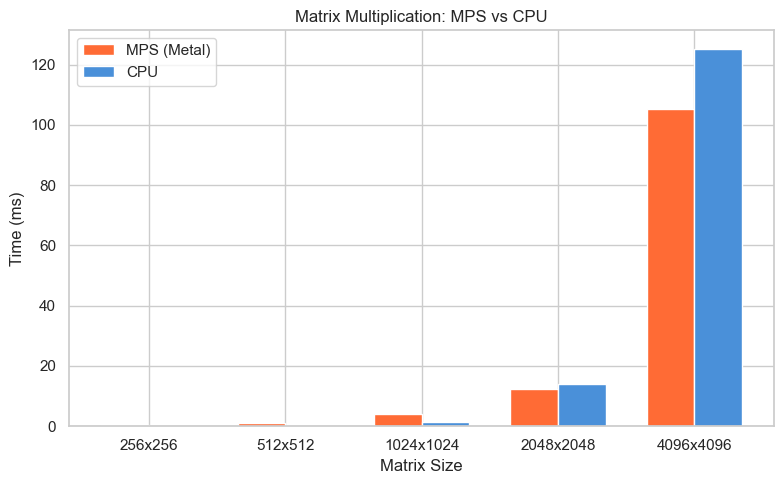

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

x = range(len(sizes))
width = 0.35

if mps_times:
    ax.bar([i - width / 2 for i in x], mps_times, width, label="MPS (Metal)", color="#FF6B35")
ax.bar([i + width / 2 for i in x], cpu_times, width, label="CPU", color="#4A90D9")

ax.set_xlabel("Matrix Size")
ax.set_ylabel("Time (ms)")
ax.set_title("Matrix Multiplication: MPS vs CPU")
ax.set_xticks(list(x))
ax.set_xticklabels([f"{s}x{s}" for s in sizes])
ax.legend()

plt.tight_layout()
plt.show()

## 4. Speedup Summary

In [15]:
if mps_times and cpu_times:
    import pandas as pd
    df = pd.DataFrame({
        "Size": [f"{s}x{s}" for s in sizes],
        "MPS (ms)": [f"{t:.2f}" for t in mps_times],
        "CPU (ms)": [f"{t:.2f}" for t in cpu_times],
        "Speedup": [f"{c / m:.1f}x" for c, m in zip(cpu_times, mps_times)],
    })
    display(df)
else:
    print("MPS not available — ran CPU only.")

,Size,MPS (ms),CPU (ms),Speedup
0,256x256,0.60,0.03,0.1x
1,512x512,1.02,0.17,0.2x
2,1024x1024,4.70,1.39,0.3x
3,2048x2048,12.20,13.00,1.1x
4,4096x4096,94.55,125.98,1.3x
5,8192x8192,943.25,1180.23,1.3x
